# Global Power Plants: Energy Transition Audit

**Objective:** Analyze whether global infrastructure is shifting from fossil fuels toward renewable energy using capacity distribution, age trends, and predictive classification.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.compose import ColumnTransformer
sns.set_theme(style="whitegrid")
os.makedirs('figures', exist_ok=True)
df = pd.read_csv("global_power_plant_database.csv", low_memory=False)
df.columns = df.columns.str.strip()
print(df.shape)
df.head()

ModuleNotFoundError: No module named 'pandas'

## Data Preparation

Before cleaning: 34936 rows
Full dataset: 21808 rows
Temporal dataset: 13340 rows


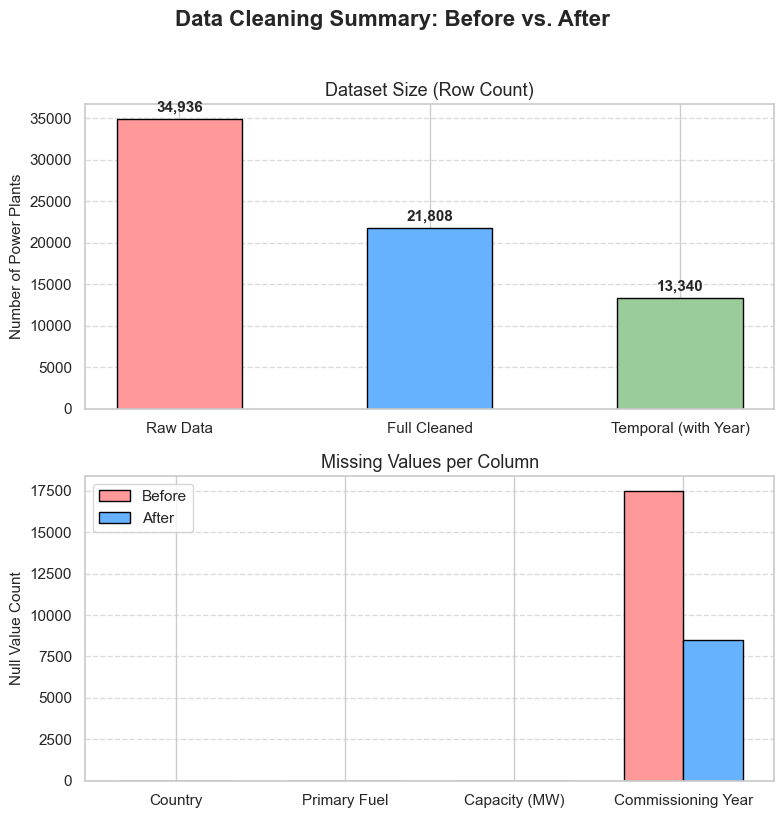

In [ ]:
df = df[['country_long', 'primary_fuel', 'capacity_mw', 'commissioning_year']]
df_before = df.copy()
print(f"Before cleaning: {len(df_before)} rows")

df_full = df[df['capacity_mw'] > 0].copy()
df_full = df_full.dropna(subset=['country_long', 'primary_fuel', 'capacity_mw'])
df_full = df_full.drop_duplicates()

df_full.columns = ['Country', 'Primary_Fuel', 'Capacity_MW', 'Commissioning_Year']
df_temporal = df_full.dropna(subset=['Commissioning_Year']).copy()
df_temporal['Plant_Age'] = 2026 - df_temporal['Commissioning_Year']

print(f"Full dataset: {len(df_full)} rows")
print(f"Temporal dataset: {len(df_temporal)} rows")

renewable_fuels = ['Solar', 'Wind', 'Hydro', 'Biomass', 'Geothermal']
for d in [df_full, df_temporal]:
    d['Energy_Type'] = d['Primary_Fuel'].apply(
        lambda x: 'Renewable' if x in renewable_fuels else 'Non-Renewable'
    )

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 8))
fig.suptitle('Data Cleaning Summary: Before vs. After', fontsize=16, fontweight='bold', y=1.02)

categories = ['Raw Data', 'Full Cleaned', 'Temporal (with Year)']
counts = [len(df_before), len(df_full), len(df_temporal)]
colors = ['#FF9999', '#66B2FF', '#99CC99']

bars = ax1.bar(categories, counts, color=colors, edgecolor='black', width=0.5)
ax1.set_title('Dataset Size (Row Count)', fontsize=13)
ax1.set_ylabel('Number of Power Plants', fontsize=11)
ax1.grid(axis='y', linestyle='--', alpha=0.7)

for bar in bars:
    yval = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, yval + 500, f'{yval:,}', ha='center', va='bottom', fontsize=11, fontweight='bold')

missing_before = df_before[['country_long', 'primary_fuel', 'capacity_mw', 'commissioning_year']].isnull().sum()
missing_before.index = ['Country', 'Primary_Fuel', 'Capacity_MW', 'Commissioning_Year']
missing_after = df_full[['Country', 'Primary_Fuel', 'Capacity_MW', 'Commissioning_Year']].isnull().sum()

x = range(len(missing_before))
width = 0.35

ax2.bar([i - width/2 for i in x], missing_before, width, label='Before', color='#FF9999', edgecolor='black')
ax2.bar([i + width/2 for i in x], missing_after, width, label='After', color='#66B2FF', edgecolor='black')

ax2.set_title('Missing Values per Column', fontsize=13)
ax2.set_ylabel('Null Value Count', fontsize=11)
ax2.set_xticks(x)
ax2.set_xticklabels(['Country', 'Primary Fuel', 'Capacity (MW)', 'Commissioning Year'], rotation=0)
ax2.legend()
ax2.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig('figures/data_cleaning_audit.png', dpi=300, bbox_inches='tight')
plt.show()

**Bias Note:** `df_full` retains all plants with valid country, fuel, and capacity data. `df_temporal` further filters to plants with a known commissioning year. The dropped records are disproportionately older plants and facilities in developing regions, meaning capacity figures in `df_full` still undercount global fossil infrastructure.

## Global Energy Capacity Analysis

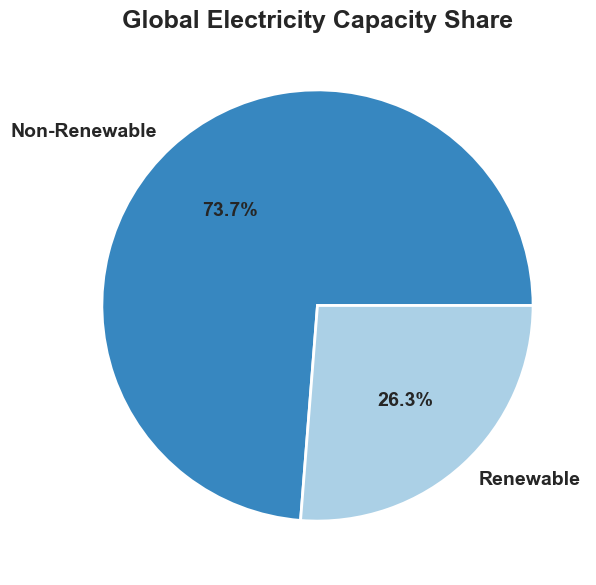

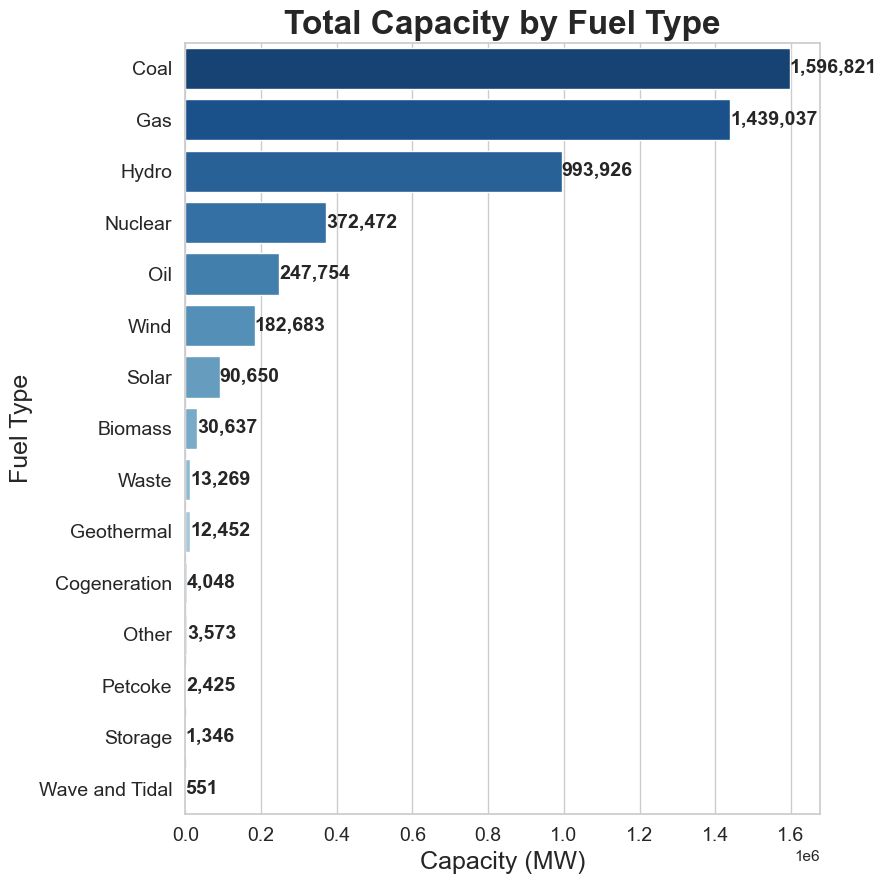

In [ ]:
capacity_summary = df_full.groupby('Energy_Type')['Capacity_MW'].sum()

plt.figure(figsize=(7, 7))
plt.pie(capacity_summary, labels=capacity_summary.index, autopct='%1.1f%%', colors=sns.color_palette("Blues_r", 2), 
        wedgeprops={"edgecolor": "white", "linewidth": 2}, textprops={'fontsize': 14, 'weight': 'bold'})
plt.title("Global Electricity Capacity Share", fontsize=18, fontweight='bold')
plt.savefig('figures/capacity_pie.png', dpi=300, bbox_inches='tight')
plt.show()

fuel_capacity = df_full.groupby('Primary_Fuel')['Capacity_MW'].sum().sort_values(ascending=False)

plt.figure(figsize=(9, 9))
ax = sns.barplot(
    x=fuel_capacity.values,
    y=fuel_capacity.index,
    hue=fuel_capacity.index,
    palette="Blues_r",
    legend=False
)

plt.title("Total Capacity by Fuel Type", fontsize=24, fontweight='bold')
plt.xlabel("Capacity (MW)", fontsize=18)
plt.ylabel("Fuel Type", fontsize=18)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

for bar in ax.patches:
    ax.text(
        bar.get_width(),
        bar.get_y() + bar.get_height()/2,
        f"{bar.get_width():,.0f}",
        ha='left',
        va='center',
        fontsize=14,
        fontweight='bold'
    )

plt.tight_layout()
plt.savefig('figures/fuel_bar.png', dpi=300, bbox_inches='tight')
plt.show()

## Infrastructure Age Analysis

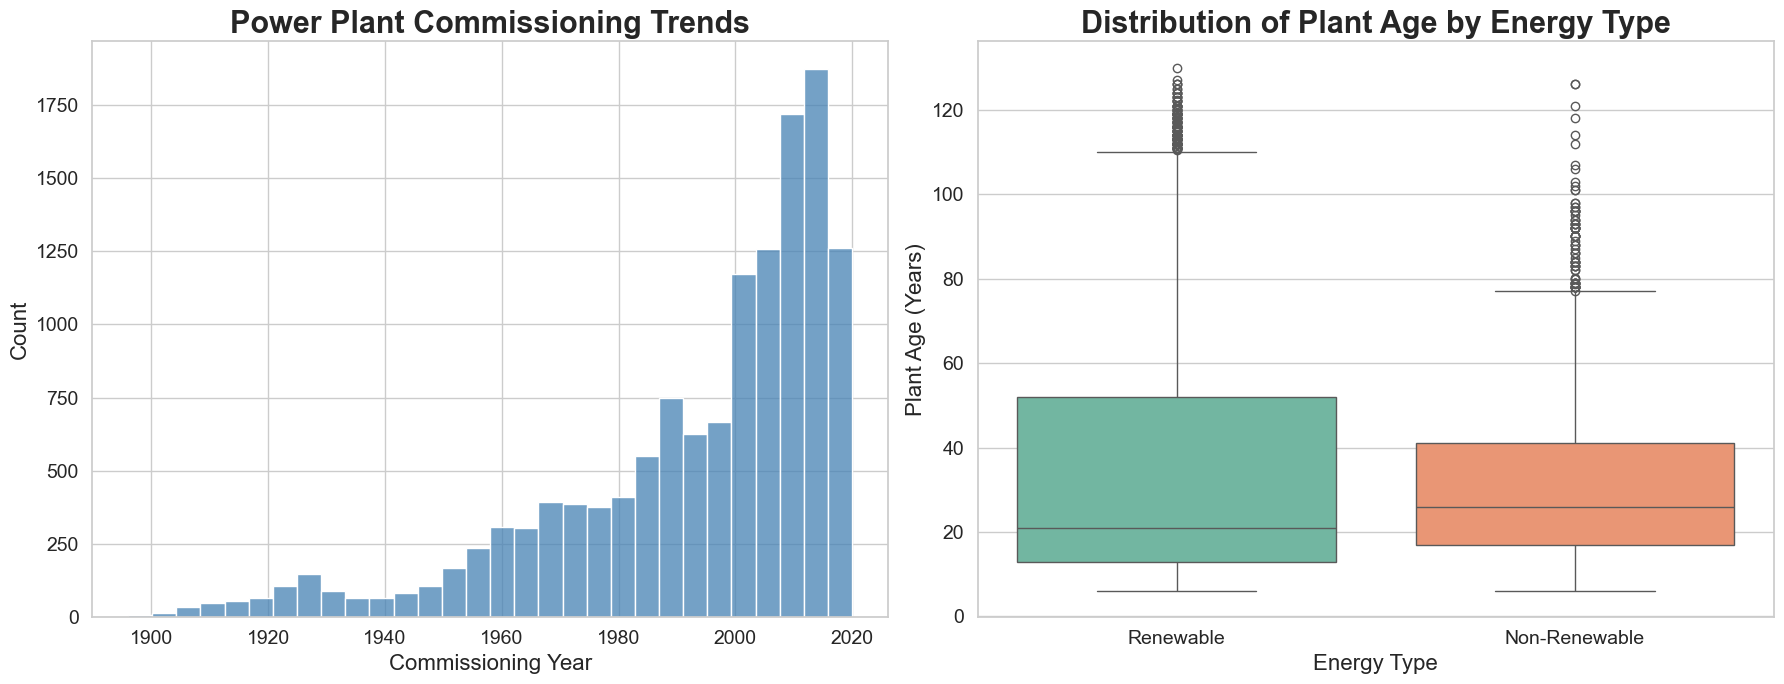

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.histplot(
    data=df_temporal,
    x='Commissioning_Year',
    bins=30,
    color="steelblue",
    ax=axes[0]
)
axes[0].set_title("Power Plant Commissioning Trends", fontsize=22, fontweight='bold')
axes[0].set_xlabel("Commissioning Year", fontsize=16)
axes[0].set_ylabel("Count", fontsize=16)
axes[0].tick_params(axis='both', labelsize=14)

sns.boxplot(
    data=df_temporal,
    x='Energy_Type',
    y='Plant_Age',
    hue='Energy_Type',
    palette="Set2",
    legend=False,
    ax=axes[1]
)
axes[1].set_title("Distribution of Plant Age by Energy Type", fontsize=22, fontweight='bold')
axes[1].set_xlabel("Energy Type", fontsize=16)
axes[1].set_ylabel("Plant Age (Years)", fontsize=16)
axes[1].tick_params(axis='both', labelsize=14)

plt.tight_layout()
plt.savefig('figures/age_trends.png', dpi=300, bbox_inches='tight')
plt.show()

## Renewable Capacity Breakdown

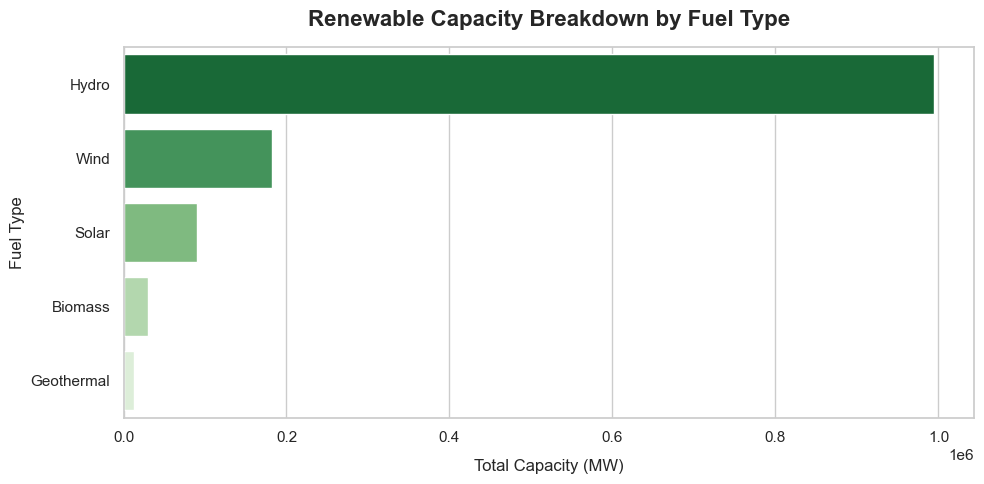

In [ ]:
renewable_df = df_full[df_full['Energy_Type'] == 'Renewable']
renewable_breakdown = renewable_df.groupby('Primary_Fuel')['Capacity_MW'].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(
    x=renewable_breakdown.values, 
    y=renewable_breakdown.index, 
    palette="Greens_r",
    hue=renewable_breakdown.index,
    legend=False
)
plt.title("Renewable Capacity Breakdown by Fuel Type", fontsize=16, fontweight='bold', pad=15)
plt.xlabel("Total Capacity (MW)", fontsize=12, labelpad=10)
plt.ylabel("Fuel Type", fontsize=12)
plt.tight_layout()
plt.savefig('figures/renewable_breakdown_appendix.png', dpi=300, bbox_inches='tight')
plt.show()

## Primary Predictive Model: Random Forest

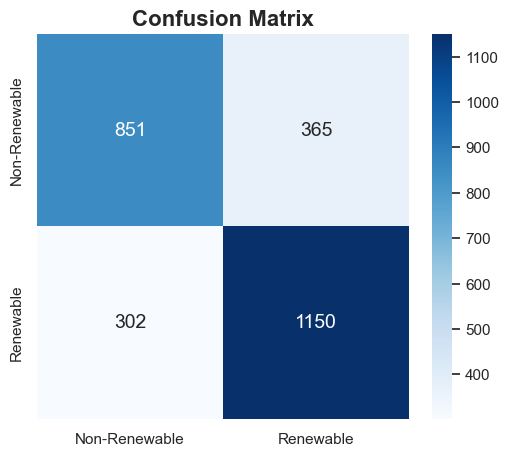


Classification Report:
               precision    recall  f1-score   support

Non-Renewable       0.74      0.70      0.72      1216
    Renewable       0.76      0.79      0.78      1452

     accuracy                           0.75      2668
    macro avg       0.75      0.75      0.75      2668
 weighted avg       0.75      0.75      0.75      2668



In [ ]:
df_encoded = pd.get_dummies(df_temporal, columns=['Country'], drop_first=True)
le_target = LabelEncoder()
df_encoded['Target'] = le_target.fit_transform(df_encoded['Energy_Type'])
df_encoded = df_encoded.drop(columns=['Commissioning_Year', 'Primary_Fuel', 'Energy_Type'])

feature_columns = ['Capacity_MW', 'Plant_Age'] + [col for col in df_encoded.columns if col.startswith('Country_')]
X, y = df_encoded[feature_columns], df_encoded['Target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42, class_weight='balanced')
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues', annot_kws={"size": 14}, 
            xticklabels=le_target.classes_, yticklabels=le_target.classes_)
plt.title("Confusion Matrix", fontsize=16, fontweight='bold')
plt.savefig('figures/confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=le_target.classes_))

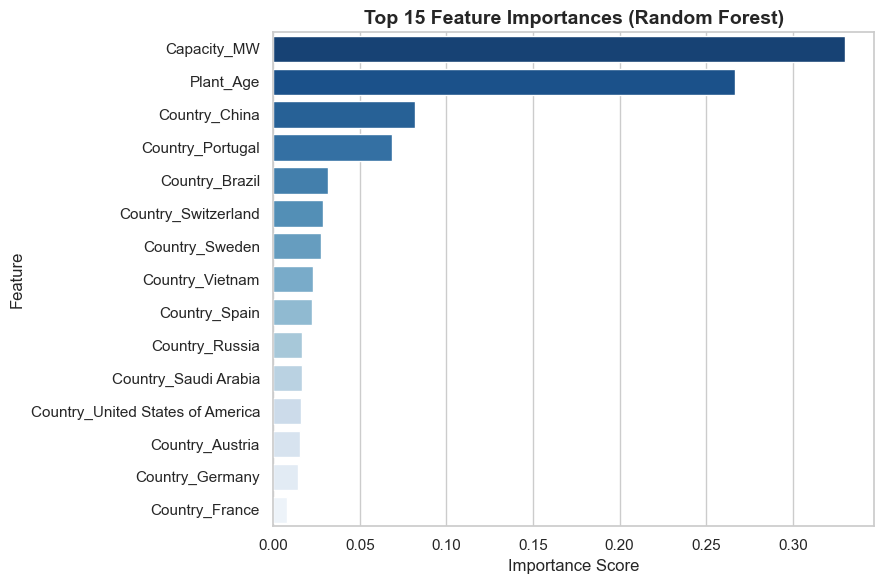

In [ ]:
importances = pd.Series(model.feature_importances_, index=feature_columns)
top_features = importances.sort_values(ascending=False).head(15)

plt.figure(figsize=(9, 6))
sns.barplot(x=top_features.values, y=top_features.index, palette="Blues_r", hue=top_features.index, legend=False)
plt.title("Top 15 Feature Importances (Random Forest)", fontsize=14, fontweight='bold')
plt.xlabel("Importance Score", fontsize=12)
plt.ylabel("Feature", fontsize=12)
plt.tight_layout()
plt.savefig('figures/feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

## Model Comparison

In [ ]:
continuous_cols = ['Capacity_MW', 'Plant_Age']
dummy_cols = [col for col in feature_columns if col.startswith('Country_')]

X = df_encoded[feature_columns]
y = df_encoded['Target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

preprocess = ColumnTransformer([
    ("num", StandardScaler(), continuous_cols),
    ("cat", "passthrough", dummy_cols)
])

X_train_scaled = preprocess.fit_transform(X_train)
X_test_scaled = preprocess.transform(X_test)

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=5, class_weight='balanced', random_state=42),
    'SVM': SVC(kernel='rbf', class_weight='balanced', random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=5)
}

results = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)
    results[name] = round(accuracy_score(y_test, preds), 4)

print("Majority class baseline:", round(y_test.value_counts(normalize=True).max(), 4))
print()

for name, acc in sorted(results.items(), key=lambda x: -x[1]):
    print(f"{name}: {acc}")

Majority class baseline: 0.5262

SVM: 0.7834
KNN: 0.7766
Random Forest: 0.7672
Logistic Regression: 0.6582


## Conclusion

This analysis explored global power plant infrastructure to understand the balance between renewable and non-renewable energy sources, as well as how different characteristics of power plants relate to their energy type.

### Key findings
- Global electricity capacity is still dominated by non-renewable sources, although renewables show strong presence across multiple fuel types.
- Plant age distributions suggest that renewable infrastructure is generally newer compared to fossil-based infrastructure.
- Capacity and plant age, along with geographic information, provide meaningful signals for distinguishing between renewable and non-renewable energy sources.

### Predictive modeling
Multiple classification models were tested, including Logistic Regression, Random Forest, KNN, and SVM. SVM and KNN achieved slightly higher accuracy (~77–78%), while Random Forest performed comparably (~76%) and was selected as the primary model due to its robustness and interpretability. Logistic Regression underperformed relative to non-linear models, indicating that the relationship between features and target is not strictly linear.

### Overall insight
While renewable energy infrastructure is growing, global energy systems still show strong structural dependence on fossil fuel-based capacity. The models demonstrate that energy type can be reasonably inferred from operational and geographic features, but performance differences between models are small, suggesting a shared predictive limit given the current feature set.